In [1]:
import wandb
import numpy as np
import yaml
from utilities.utils import correct_type_of_entry, get_exp_file_name, create_all_configs, get_min_max_loss
import json
import pandas as pd
from itertools import product
import os

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['bright'])

/Users/mathieubazinet/Documents/PythonProjects/ncp2l/ncp2lEnv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def slicen(n):
    return (slice(None),)*n


zero_one_loss = True

if zero_one_loss:
    choosing_parameter = "full_disagreement_bound_p2l"
    # choosing_parameter = "validation_error"
    values_to_fetch = ['complement_error', 'validation_error', 'test_error', 'best_model_complement_error','best_model_test_error',
                       'p2l_bound', 'disagreement_brute_force', 'full_disagreement_bound_p2l', 'compression_set_size', 'train_set_size']
else:
    choosing_parameter = "full_disagreement_loss"
    # choosing_parameter = "validation_loss"
    values_to_fetch = ['complement_loss', 'validation_loss', 'test_loss', 'best_model_complement_loss', 'best_model_test_loss','CE_kl_bound',
                       'disagreement_loss_kl', 'full_disagreement_loss', 'compression_set_size', 'train_set_size']
    

In [ ]:
results_list = []
dataset_list = []

for dataset in ['mnist', 'cifar10']:
    dataset_config_name = "./configs/dataset_configs/" + dataset + ".yaml"
    with open(dataset_config_name) as file:
        dataset_configuration = yaml.safe_load(file)
    
    sweep_config_name = "./configs/experiment_configs/p2l/" + dataset + ".yaml"
    with open(sweep_config_name) as file:
        sweep_configuration = yaml.safe_load(file)
    
    hps = {}
    for key, item in sweep_configuration['parameters'].items():
        if item.get('values', None) is not None:
            hps[key] = correct_type_of_entry(item['values'])
    size_hyperparams = tuple([len(l) for l in hps.values()])
    
    results_matrix = np.ones(((len(values_to_fetch),) + size_hyperparams))
    results_matrix[:] = np.nan
    
    for sweep_config in create_all_configs(sweep_configuration):
        file_name = get_exp_file_name(sweep_config|dataset_configuration, path="./experiment_logs/")
        if os.path.exists(file_name):
            with open(file_name) as f:
                config = json.load(f)
                for val_to_fetch_idx in range(len(values_to_fetch)):
                    matrix_idx = tuple([val_to_fetch_idx] + [hps[key].index(config['config'].get(key, None)) for key in hps.keys()])
                    val_to_fetch = values_to_fetch[val_to_fetch_idx]
                    results_matrix[matrix_idx] = config.get(val_to_fetch, None)
    
    hp_list = list(hps.values())[1:]
    params_product = list(product(*hp_list))
    name_list = []
    idx_list = []
    for params in params_product:
        name = ""
        for p in params:
            name += str(p) + " "
        name_list.append(name[:-1])
        idx = ()
        for p_idx in range(len(params)):
            p_key = list(hps.keys())[1:][p_idx]
            idx += (hps[p_key].index(params[p_idx]),)
        idx_list.append(tuple(idx))
    
    reshaped_matrix = np.nanmean(results_matrix, axis=1).reshape(results_matrix.shape[0],np.prod(results_matrix.shape[2:])).T
    mean_df = pd.DataFrame(reshaped_matrix, index=name_list, columns=values_to_fetch)
    
    reshaped_matrix_std = np.nanstd(results_matrix, axis=1).reshape(results_matrix.shape[0],np.prod(results_matrix.shape[2:])).T
    std_df = pd.DataFrame(reshaped_matrix_std, index=name_list, columns=values_to_fetch)
    
    if "model_type" in list(hps.keys()):
        list_indexs = [[] for _ in range(len(hps['model_type']))]
        for name in list(mean_df.index):
            for model_idx in range(len(hps['model_type'])):
                if hps['model_type'][model_idx] in name:
                    list_indexs[model_idx].append(name)
                    break
    else:
        list_indexs = [list(mean_df.index)]
    
    for i in range(len(list_indexs)):
        index_mean = mean_df.loc[list_indexs[i]].sort_values(by=choosing_parameter).index[0]
        
        best_datapoint_mean = mean_df.loc[index_mean]
        best_datapoint_std = std_df.loc[index_mean]
        
        if "model_type" in list(hps.keys()):
            if hps['model_type'][i] == "cnn":
                mt = "CNN"
            elif hps['model_type'][i] == "resnet":
                mt = "ResNet18"
            else:
                raise NotImplementedError
        else:
            mt = "CNN"
    
        rounding_val = 2 if zero_one_loss else 4
        rounding = f"%.{rounding_val}f"
        
        mult = 100.0 if zero_one_loss else 1.0
        
        cpr = (rounding % round(100*best_datapoint_mean['compression_set_size']/best_datapoint_mean['train_set_size'],rounding_val)) + r"$\pm$"
        cpr += (rounding % round(100*best_datapoint_std['compression_set_size']/best_datapoint_mean['train_set_size'],rounding_val))
    
        if zero_one_loss:
            vals_to_add = ["Model", 'complement_error', 'test_error', "cpr", 'best_model_complement_error', 'best_model_test_error',
                            'p2l_bound', 'disagreement_brute_force', 'full_disagreement_bound_p2l']
        else:
            vals_to_add = ["Model", 'complement_loss', 'test_loss', "cpr", 'best_model_complement_loss',
                           'best_model_test_loss', 'CE_kl_bound', 'disagreement_loss_kl', 'full_disagreement_loss']
    
        list_of_vals = []
        for val in vals_to_add:
            if val == "Model":
                list_of_vals.append(mt)
                continue
            elif val == "cpr":
                list_of_vals.append(cpr)
                continue
    
            temp = (rounding % round(mult*best_datapoint_mean[val],rounding_val)) + r"$\pm$"
            temp += (rounding % round(mult*best_datapoint_std[val], rounding_val))
            list_of_vals.append(temp)
    
        results_list.append(pd.Series(list_of_vals, index=vals_to_add))
            
        dataset_list.append(dataset.upper())

if zero_one_loss:
    print(pd.DataFrame(results_list, index=dataset_list).to_latex(float_format="%.2f"))
else:
    print(pd.DataFrame(results_list, index=dataset_list).to_latex(float_format="%.4f"))

\begin{tabular}{llllllllll}
\toprule
 & Model & complement_error & test_error & cpr & best_model_complement_error & best_model_test_error & p2l_bound & disagreement_brute_force & full_disagreement_bound_p2l \\
\midrule
MNIST & CNN & 0.00$\pm$0.00 & 0.59$\pm$0.04 & 2.73$\pm$0.04 & 0.29$\pm$0.03 & 0.50$\pm$0.07 & 2.92$\pm$0.04 & 0.82$\pm$0.09 & 3.74$\pm$0.07 \\
CIFAR10 & CNN & 0.00$\pm$0.00 & 16.68$\pm$1.66 & 47.36$\pm$2.18 & 0.00$\pm$0.00 & 9.24$\pm$0.10 & 48.13$\pm$2.19 & 15.68$\pm$1.79 & 63.81$\pm$3.92 \\
CIFAR10 & ResNet18 & 0.00$\pm$0.00 & 6.88$\pm$0.10 & 49.28$\pm$2.78 & 0.00$\pm$0.00 & 5.84$\pm$0.16 & 50.05$\pm$2.78 & 6.74$\pm$0.16 & 56.79$\pm$2.71 \\
\bottomrule
\end{tabular}



# WANDB api

In [35]:
dataset = "mnist"
api = wandb.Api(timeout=29)
entity = "mathieu-bazinet"
project = "sweep" + dataset + "_ckpt"
runs = api.runs(entity + "/" + project)

In [37]:
100 * runs[15].history(keys=['compression_set_size'], pandas=True)['compression_set_size']/ runs[15].summary['train_set_size']

0      0.000000
1      0.011574
2      0.023148
3      0.034722
4      0.046296
         ...   
245    2.835648
246    2.847222
247    2.858796
248    2.870370
249    2.875000
Name: compression_set_size, Length: 250, dtype: float64

In [16]:
min_val = 1.0
min_idx = 0
for i, run in enumerate(runs):
    if run.state != "finished":
        continue

    hist = run.history(keys=['p2l_bound'], pandas=True)
    if hist['p2l_bound']

[<Run mathieu-bazinet/sweepcifar10_ckpt/1c90ukwy (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/lzszmpty (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/w49u3g22 (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/rhwswixh (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/dlrv0x0o (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/chj9mwxi (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/ast3oj04 (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/gbodc8z7 (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/vxp9vrog (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/mnugve98 (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/7mc20y48 (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/e69q3629 (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/lhi6pegt (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/wgzsowbu (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/vvthz226 (finished)>,
 <Run mathieu-bazinet/sweepcifar10_ckpt/99tbl3ba (finished)>,
 <Run ma

In [34]:
val_to_fetch = ["complement_error", 'kl_bound', 'compression_set_size']
history_df = runs[15].history(keys=val_to_fetch, pandas=True)
history_df

,_step,complement_error,kl_bound,compression_set_size
0,0,0.900001,0.907267,0
1,11,0.900001,0.991541,1280
2,22,0.900001,0.997512,2560
3,33,0.900001,0.999133,3840
4,44,0.425181,0.849951,5120
5,55,0.276078,0.778114,6400
6,66,0.205004,0.752029,7680
7,77,0.150704,0.734186,8960
8,88,0.102433,0.716572,10240
9,99,0.068113,0.708294,11520


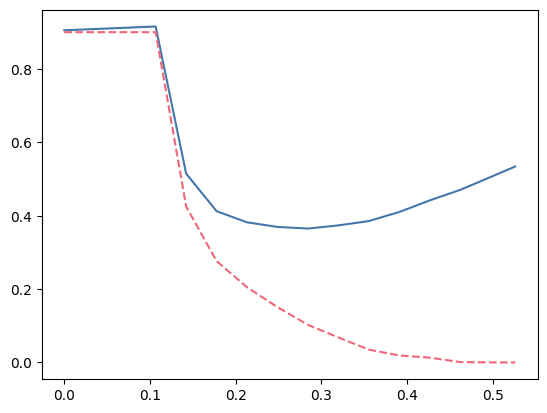

In [13]:
plt.plot(history_df['compression_set_size'] / runs[15].summary['train_set_size'], history_df['p2l_bound'])
plt.plot(history_df['compression_set_size'] / runs[15].summary['train_set_size'], history_df['complement_error'], linestyle="--")